In [ ]:
#install required data
#!pip install hecdss --break-system-packages

In [1]:
#import required data
import pandas as pd
from hecdss import HecDss
from datetime import datetime

In [18]:
#open the observed data, select sheet and clip columns
dfRaw = pd.read_csv('../Xls/flowMiamiRiver.csv')
dfRaw = dfRaw[['SW2','flowm3s']]
dfRaw.head()

,SW2,flowm3s
0,2023-01-01 00:00:00,11.027596
1,2023-01-01 01:00:00,11.228128
2,2023-01-01 02:00:00,11.668551
3,2023-01-01 03:00:00,11.871946
4,2023-01-01 04:00:00,12.207158


In [19]:
dfRaw.tail()

,SW2,flowm3s
1435,2023-03-01 19:00:00,35.512041
1436,2023-03-01 20:00:00,34.991528
1437,2023-03-01 21:00:00,34.908219
1438,2023-03-01 22:00:00,34.681315
1439,2023-03-01 23:00:00,33.504535


In [23]:
#import data on a correct format
dfHeads = pd.DataFrame()
dfHeads.index=pd.to_datetime(dfRaw['SW2'])
dfHeads['Flow m3/s'] = pd.to_numeric(dfRaw['flowm3s']).to_list()
dfHeads.head()

,Flow m3/s
SW2,
2023-01-01 00:00:00,11.027596
2023-01-01 01:00:00,11.228128
2023-01-01 02:00:00,11.668551
2023-01-01 03:00:00,11.871946
2023-01-01 04:00:00,12.207158


<AxesSubplot: xlabel='SW2'>

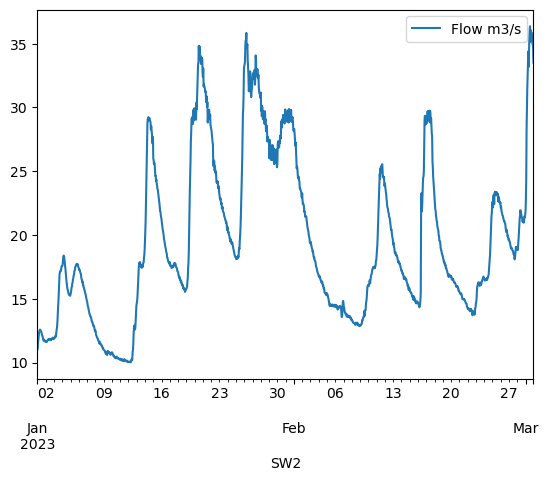

In [24]:
#plot histogram
dfHeads.plot()

In [25]:
from pydsstools.core import TimeSeriesContainer, UNDEFINED
from pydsstools.heclib.dss import HecDss

# 2. Extract arrays
times = dfHeads.index.tolist()
values = dfHeads['Flow m3/s'].astype(float).tolist()

dss_file = "../Xls/riverFlowSw2.dss"
pathname = "/THEISNASH/SW1/FLOW//1HOUR/OBSERVED/"

with HecDss.Open(dss_file) as fid:
    count = len(values)
    interval = 1  # positive = regular time series

    tsc = TimeSeriesContainer(pathname, count, interval)
    tsc.start_time = times[0]
    tsc.data_units = "CMS"
    tsc.data_type = "INST-VAL"
    tsc.tzid = "UTC"
    tsc.values = values  # UNDEFINED marks missing data

    fid.put_ts(tsc)

16:24:54.394      -----DSS---zopen   New file opened,  File: ../Xls/riverFlowSw2.dss
16:24:54.394                         Handle 71;  Process: 1763;  DSS Version:  7-IV
16:24:54.395                         Single-user advisory access mode
16:24:54.418 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Dec2022/1Hour/OBSERVED/
16:24:54.423 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Jan2023/1Hour/OBSERVED/
16:24:54.430 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Feb2023/1Hour/OBSERVED/
16:24:54.436 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW1/FLOW/01Mar2023/1Hour/OBSERVED/
16:24:54.439      -----DSS---zclose  Handle 71;  Process: 1763;  File: ../Xls/riverFlowSw2.dss
16:24:54.440                         Number records:         4
16:24:54.440                         File size:              16690  64-bit words
16:24:54.440                         File size:              130 Kb;  0 Mb
16:24:54.440                       

In [26]:
# 2. Extract arrays
times = dfHeads.index.tolist()
values = dfHeads['Flow m3/s'].astype(float).tolist()

dss_file = "../Xls/riverStageSw2.dss"
pathname = "/THEISNASH/SW2/STAGE//1HOUR/OBSERVED/"

with HecDss.Open(dss_file) as fid:
    count = len(values)
    interval = 1  # positive = regular time series

    tsc = TimeSeriesContainer(pathname, count, interval)
    tsc.start_time = times[0]
    tsc.data_units = "METERS"
    tsc.data_type = "INST"
    tsc.tzid = "UTC"
    tsc.values = values  # UNDEFINED marks missing data

    fid.put_ts(tsc)

16:35:02.396      -----DSS---zopen   New file opened,  File: ../Xls/riverStageSw2.dss
16:35:02.396                         Handle 71;  Process: 1763;  DSS Version:  7-IV
16:35:02.396                         Single-user advisory access mode
 
16:35:02.409 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW2/STAGE/01Dec2022/1Hour/OBSERVED/
16:35:02.412 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW2/STAGE/01Jan2023/1Hour/OBSERVED/
16:35:02.416 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW2/STAGE/01Feb2023/1Hour/OBSERVED/
16:35:02.420 -----DSS--- zwrite  Handle 71;  Version 1:  /THEISNASH/SW2/STAGE/01Mar2023/1Hour/OBSERVED/
16:35:02.421      -----DSS---zclose  Handle 71;  Process: 1763;  File: ../Xls/riverStageSw2.dss
16:35:02.421                         Number records:         4
16:35:02.421                         File size:              16686  64-bit words
16:35:02.421                         File size:              130 Kb;  0 Mb
16:35:02.421               